In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [13]:
#load the dataset
df=pd.read_csv('ecommerce_bigdata.csv')


In [14]:
# display the first few rows of the dataset
df.head()

,TransactionID,Date,Region,ProductCategory,CustomerType,Sales,Profit
0,TX0001,2026-06-16,Eastern,Electronics,Wholesale,4924,359.44
1,TX0002,2026-02-12,Central,Electronics,Retail,3283,944.32
2,TX0003,2026-03-01,Northern,Food,Online,4049,967.10
3,TX0004,2026-06-03,Western,Household Products,Online,4331,434.57
4,TX0005,2026-01-21,Western,Household Products,Retail,3283,340.48


In [15]:
#preprocess the data
#check for missing values
df.isnull().sum()

TransactionID      0
Date               0
Region             0
ProductCategory    0
CustomerType       0
Sales              0
Profit             0
dtype: int64

In [16]:
#summary statistics of the data
df.describe()

,Sales,Profit
count,200.000000,200.000000
mean,2567.190000,456.367350
std,1528.736925,346.853151
min,56.000000,5.130000
25%,1200.500000,173.967500
50%,2428.000000,379.330000
75%,4052.000000,675.000000
max,4998.000000,1377.040000


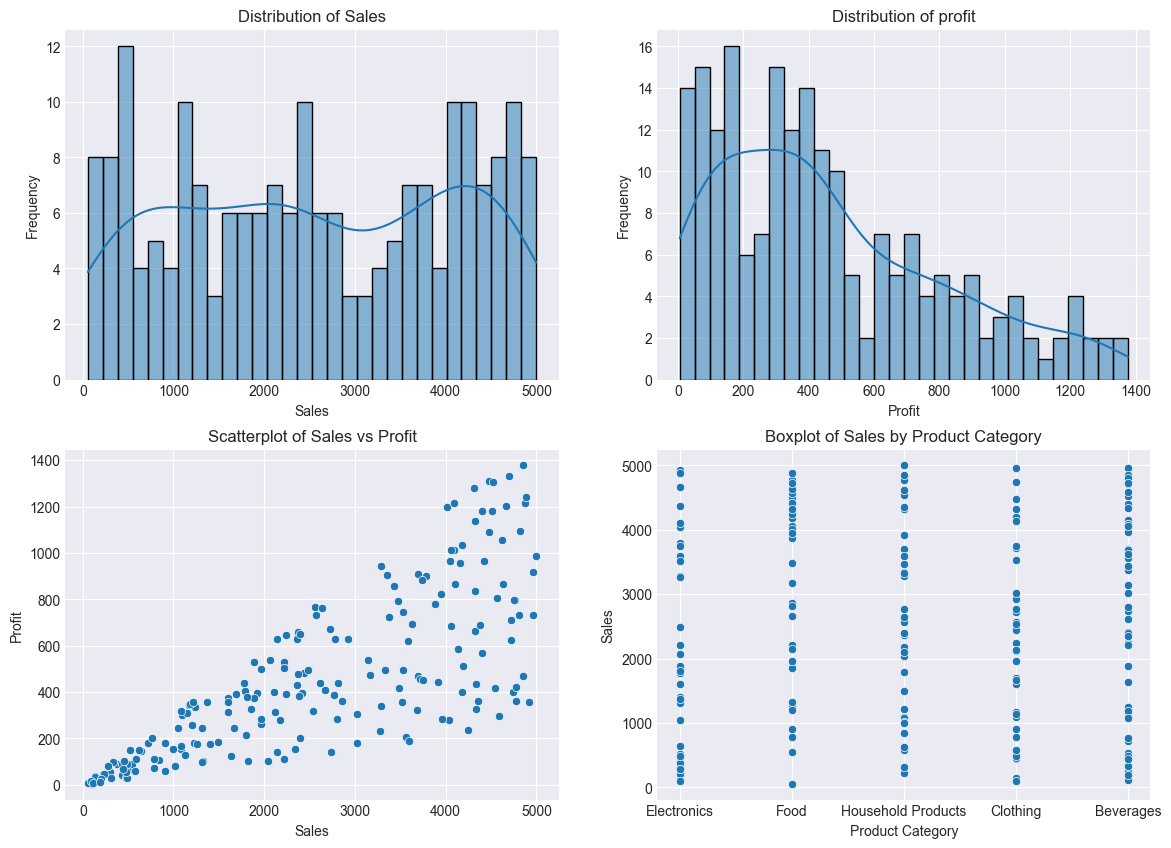

In [17]:
#data visualization
#setup the plotting style
plt.style.use('seaborn-v0_8-darkgrid')
fig,axes=plt.subplots(2,2,figsize=(14,10))

#plot distribution of sales 
sns.histplot(df['Sales'],bins=30,kde=True,ax=axes[0,0])
axes[0,0].set_title('Distribution of Sales')
axes[0,0].set_xlabel('Sales')
axes[0,0].set_ylabel('Frequency')


#plot distribution of profit
sns.histplot(df['Profit'],bins=30,kde=True,ax=axes[0,1])
axes[0,1].set_title('Distribution of profit')
axes[0,1].set_xlabel('Profit')
axes[0,1].set_ylabel('Frequency')



#draw a scatterplot for sales and profit
sns.scatterplot(x='Sales',y='Profit',data=df,ax=axes[1,0])
axes[1,0].set_title('Scatterplot of Sales vs Profit')
axes[1,0].set_xlabel('Sales')
axes[1,0].set_ylabel('Profit')



#draw a boxplot for product sales by product category
sns.scatterplot(x='ProductCategory',y='Sales',data=df,ax=axes[1,1])
axes[1,1].set_title('Boxplot of Sales by Product Category')
axes[1,1].set_xlabel('Product Category')
axes[1,1].set_ylabel('Sales')
plt.show()

In [18]:
#feature engineering
df_processed=df.copy()

#convert and format dates
df_processed['Date']=pd.to_datetime(df_processed['Date'])
df_processed['Month']=df_processed['Date'].dt.month
df_processed['Day']=df_processed['Date'].dt.day
df_processed['Weekday']=df_processed['Date'].dt.weekday

In [ ]:
# converting categorical columns to numerical values
label_encoder={}
categorical_columns=['Region','ProductCategory','CustomerType']
for col in categorical_columns:
    le=LabelEncoder()
    df_processed[col+'_Encoded']=le.fit_transform(df_processed[col])
    label_encoder[col]=le
    print(f'Encoded {col}:{dict(zip(le.classes_,le.transform(le.classes_)))}')

Encoded Region:{'Central': np.int64(0), 'Eastern': np.int64(1), 'Northern': np.int64(2), 'Western': np.int64(3)}
Encoded ProductCategory:{'Beverages': np.int64(0), 'Clothing': np.int64(1), 'Electronics': np.int64(2), 'Food': np.int64(3), 'Household Products': np.int64(4)}
Encoded CustomerType:{'Online': np.int64(0), 'Retail': np.int64(1), 'Wholesale': np.int64(2)}


In [ ]:
# not all columns are useful for predictions. here we drop unnecessary columns
df_processed.drop(['TransactionID','Date','Region','ProductCategory','CustomerType'],axis=1,inplace=True)
df_processed.head()

,Sales,Profit,Month,Day,Weekday,Region_Encoded,ProductCategory_Encoded,CustomerType_Encoded
0,4924,359.44,6,16,1,1,2,2
1,3283,944.32,2,12,3,0,2,1
2,4049,967.10,3,1,6,2,3,0
3,4331,434.57,6,3,2,3,4,0
4,3283,340.48,1,21,2,3,4,1


In [23]:
#split the dataset into test and training sets
# define features and target  variable for regression task
# regression ttask: predicting profit based on sales
X_reg=df_processed.drop('Sales', axis = 1)#features all columns except profit
y_reg=df_processed['Profit'] #target variable

# split the datasets for regression
X_train_reg,X_test_reg, y_train_reg,y_test_reg=train_test_split(X_reg,y_reg,test_size=0.2,random_state=42)

# a random state??????????? 
# it is a seed value that ensures reproducibility of the results

print(f'Training set size: {X_train_reg.shape[0]} samples')
print(f'Testing set size: {X_test_reg.shape[0]} samples')

Training set size: 160 samples
Testing set size: 40 samples


In [29]:
regression_models={
    'Linear Regression':LinearRegression(),
    'Decision Tree Regressor':DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor':RandomForestRegressor(random_state=42)
}
print("\nRegression model evaluation:")
regression_results={}

for name,model in regression_models.items():
    model.fit(X_train_reg,y_train_reg)

    # make predictions on the test set
    y_pred_reg=model.predict(X_test_reg)

    # evaluate the model
    rmse=np.sqrt(mean_squared_error(y_test_reg,y_pred_reg))
    r2=r2_score(y_test_reg,y_pred_reg)

    regression_results[name]={'RMSE':rmse,'R-squared':r2}

    print(f'{name}:RMSE={rmse:.4f},R-squared={r2:.4f}')

    regression_results[name]={
        'model':model,
        'RMSE':rmse,
        'mse':mean_squared_error(y_test_reg,y_pred_reg),
        'R_squared':r2,
        'predicted_profit':y_pred_reg
    }

    print(f"{name} model trained and evaluated successfully")
    print(f"Mean Squared Error (MSE): {regression_results[name]['mse']:.2f}")
    print(f"Root mean squared error(RMSE):{regression_results[name]['RMSE']:.4f}")
    print(f"R-squared:{regression_results[name]['R_squared']:.4f}")
    print(f"Interpretation:{regression_results[name]['predicted_profit'][:5]}")




Regression model evaluation:
Linear Regression:RMSE=0.0000,R-squared=1.0000
Linear Regression model trained and evaluated successfully
Mean Squared Error (MSE): 0.00
Root mean squared error(RMSE):0.0000
R-squared:1.0000
Interpretation:[ 41.94 905.95 496.96 712.17 587.69]
Decision Tree Regressor:RMSE=23.4780,R-squared=0.9951
Decision Tree Regressor model trained and evaluated successfully
Mean Squared Error (MSE): 551.21
Root mean squared error(RMSE):23.4780
R-squared:0.9951
Interpretation:[ 40.04 899.24 510.68 725.   567.64]
Random Forest Regressor:RMSE=7.0460,R-squared=0.9996
Random Forest Regressor model trained and evaluated successfully
Mean Squared Error (MSE): 49.65
Root mean squared error(RMSE):7.0460
R-squared:0.9996
Interpretation:[ 42.0606 901.0267 503.4806 716.9479 586.7901]


In [ ]:
# classification
# logistic regression
# decission tree classifier
# random forest classifier

classification_models={
    'Logistic Regression':LogisticRegression(),
    'Decision Tree Classifier':DecisionTreeClassifier(),
    'Random Forest Classifier': RandomForestClassifier()
}

classification_results={}

print(f"\nClassification model evaluation")

for name,model in classification_models.items():
    pass

In [ ]:
# visualization of the sults and interpret the findings

In [ ]:
# visualize using confusion matrix